<a href="https://colab.research.google.com/github/kirtanjoshi/AI--Assesment/blob/main/Part3_NLP_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Movie Reviews using RNN, LSTM, and Word2Vec Embeddings
## Part III – Language Tasks | 6CS012 – Artificial Intelligence and Machine Learning
### Herald College Kathmandu | University of Wolverhampton

---
**Dataset:** IMDb Movie Review Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Simple RNN | LSTM | LSTM + Word2Vec  

---

## 1. Install Dependencies & Import Libraries

In [1]:
# Update libraries to ensure compatibility
!pip install --upgrade jax jaxlib
!pip install gensim wordcloud
# Note: Removing forced numpy==1.23.5 as it often conflicts with modern JAX/TF in Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 9.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.3 MB/s eta 0:00:00


In [2]:
# ── Standard Libraries ──
import os
import re
import string
import warnings
import time
warnings.filterwarnings('ignore')

# ── Data Handling ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# ── NLP Preprocessing ──
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── Scikit-Learn ──
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# ── Keras / TensorFlow ──
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Gensim (Word2Vec) ──
import gensim.downloader as api

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")


✅ All libraries imported successfully!
TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 2. Load Dataset

The **IMDb Movie Review Dataset** is a binary sentiment analysis dataset.  
- **Labels:** `0` = Negative, `1` = Positive  
- **Split:** Pre-split into Train / Validation / Test sets


In [29]:
# ── Load CSV files ──
# If running on Google Colab, upload files or mount Google Drive first:
# from google.colab import drive
# drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/train_movie_review.csv'   # Update path if needed
VAL_PATH   = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/val_movie_review.csv'
TEST_PATH  = '/content/drive/MyDrive/Semester6_AI ML/Assesment/5. Movie Review Dataset-20260507T112750Z-3-001/5. Movie Review Dataset/test_movie_review.csv'

# ── Load CSV files ──
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Drop unnecessary index column if present
for df in [train_df, val_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

# Combine train + val, then re-split properly 80/20
full_df = pd.concat([train_df, val_df], ignore_index=True).sample(frac=1, random_state=42)
split = int(len(full_df) * 0.8)
train_df = full_df[:split]   # ✅ overwrite directly
val_df   = full_df[split:]   # ✅ overwrite directly

print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print("\nTrain Label Distribution:")
print(train_df['sentiment'].value_counts())
print("\nVal Label Distribution:")
print(val_df['sentiment'].value_counts())

print("=" * 50)
print(f"  Train set shape : {train_df.shape}")
print(f"  Val   set shape : {val_df.shape}")
print(f"  Test  set shape : {test_df.shape}")
print("=" * 50)
print("\nSample rows from training set:")
print(train_df.head(3))

Train size : 32000
Val size   : 8000

Train Label Distribution:
sentiment
0    16012
1    15988
Name: count, dtype: int64

Val Label Distribution:
sentiment
0    4027
1    3973
Name: count, dtype: int64
  Train set shape : (32000, 2)
  Val   set shape : (8000, 2)
  Test  set shape : (10000, 2)

Sample rows from training set:
                                                  review  sentiment
32823  I remember watching this film a while ago and ...          1
16298  Man, I loved this movie! This really takes me ...          1
28505  Perhaps the director was trying for another PI...          0


In [30]:
# ── Basic Info ──
print("Column names :", train_df.columns.tolist())
print("\nMissing values in train:")
print(train_df.isnull().sum())
print("\nData types:")
print(train_df.dtypes)


Column names : ['review', 'sentiment']

Missing values in train:
review       0
sentiment    0
dtype: int64

Data types:
review       object
sentiment     int64
dtype: object


---
## 3. Exploratory Data Analysis (EDA)


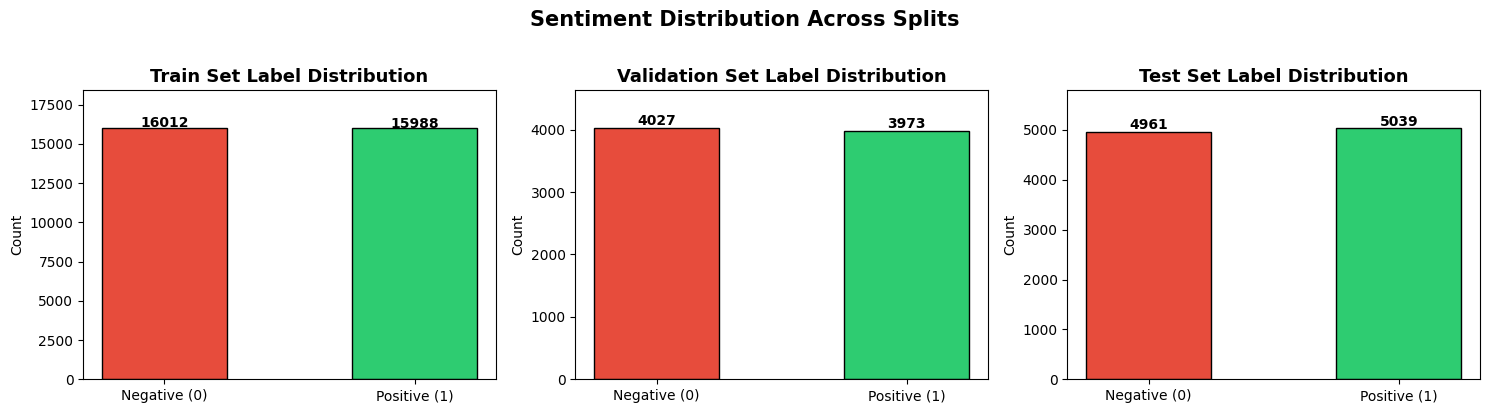

✅ Dataset is well balanced — no class imbalance issue!


In [31]:
# ── Label Distribution ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
colors = ['#e74c3c', '#2ecc71']

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{name} Set Label Distribution', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Sentiment Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset is well balanced — no class imbalance issue!")


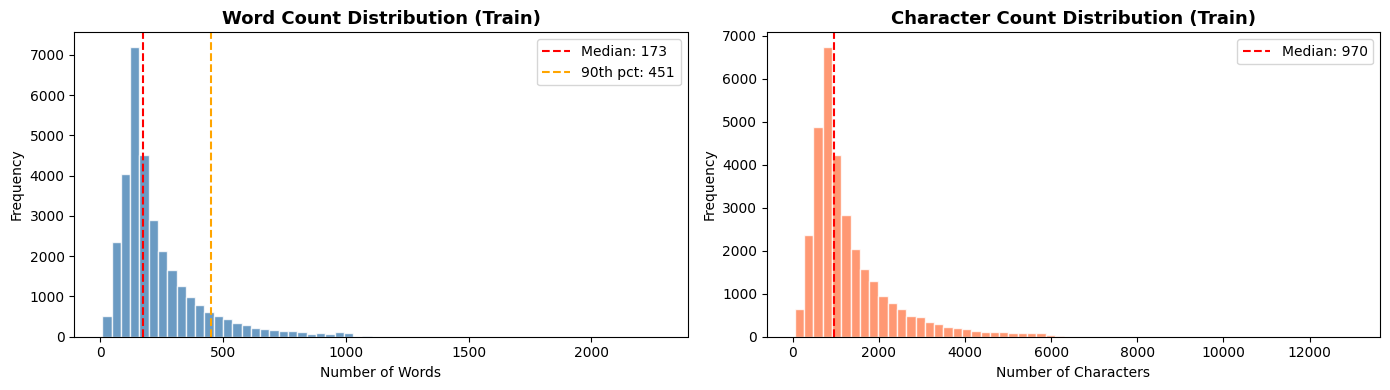

Word count stats:
count    32000.0
mean       231.0
std        171.5
min          8.0
25%        126.0
50%        173.0
75%        280.0
max       2278.0
Name: word_count, dtype: float64

50th percentile : 173 words
90th percentile : 451 words
95th percentile : 591 words


In [32]:
# ── Review Length Analysis ──
train_df['word_count'] = train_df['review'].str.split().str.len()
train_df['char_count'] = train_df['review'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train_df['word_count'].median(), color='red', linestyle='--', label=f"Median: {int(train_df['word_count'].median())}")
axes[0].axvline(np.percentile(train_df['word_count'], 90), color='orange', linestyle='--', label=f"90th pct: {int(np.percentile(train_df['word_count'], 90))}")
axes[0].set_title('Word Count Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(train_df['char_count'], bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(train_df['char_count'].median(), color='red', linestyle='--', label=f"Median: {int(train_df['char_count'].median())}")
axes[1].set_title('Character Count Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Word count stats:\n{train_df['word_count'].describe().round(1)}")
print(f"\n50th percentile : {np.percentile(train_df['word_count'], 50):.0f} words")
print(f"90th percentile : {np.percentile(train_df['word_count'], 90):.0f} words")
print(f"95th percentile : {np.percentile(train_df['word_count'], 95):.0f} words")


---
## 4. Text Preprocessing, Tokenization, and Sequence Padding

### 4.1 Text Cleaning

The following steps are applied to clean the raw review text:
1. **Lowercase** — Normalize case
2. **Remove HTML tags** — Reviews contain `<br />` tags
3. **Remove URLs** — Strip hyperlinks
4. **Remove mentions & hashtags** — @user, #tag
5. **Handle contractions** — don't → do not
6. **Remove numbers & special characters**
7. **Remove stopwords** — Common words with little semantic value
8. **Lemmatize** — Reduce words to base form


In [33]:
# ── Contractions dictionary ──
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "I'm": "I am", "I've": "I have", "I'll": "I will", "I'd": "I would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "they've": "they have", "they'll": "they will",
    "we're": "we are", "we've": "we have", "we'll": "we will",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "who's": "who is",
    "what's": "what is", "let's": "let us", "could've": "could have",
    "should've": "should have", "would've": "would have",
}

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    text = str(text).lower()                                         # 1. Lowercase
    text = re.sub(r'<.*?>', ' ', text)                               # 2. Remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)                     # 3. Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                            # 4. Remove mentions/hashtags
    text = expand_contractions(text)                                  # 5. Expand contractions
    text = re.sub(r'[^a-z\s]', ' ', text)                            # 6. Remove numbers & special chars
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens               # 7. Lemmatize
              if w not in stop_words and len(w) > 2]                 # 8. Remove stopwords & short words
    return ' '.join(tokens)

print("🔄 Cleaning texts — this may take 1-2 minutes...")
t0 = time.time()
train_df['clean_review'] = train_df['review'].apply(clean_text)
val_df['clean_review']   = val_df['review'].apply(clean_text)
test_df['clean_review']  = test_df['review'].apply(clean_text)
print(f"✅ Done in {time.time()-t0:.1f}s")

print("\nOriginal review:")
print(train_df['review'].iloc[0][:300])
print("\nCleaned review:")
print(train_df['clean_review'].iloc[0][:300])


🔄 Cleaning texts — this may take 1-2 minutes...
✅ Done in 75.5s

Original review:
I remember watching this film a while ago and after seeing 3000 miles to Graceland, it all came flooding back. Why this hasn't had a Video or DVD release yet? It's sacrilegious that this majesty of movie making has never been released while other rubbish has been. In fact this is the one John Carpen

Cleaned review:
remember watching film ago seeing mile graceland came flooding back video dvd release yet sacrilegious majesty movie making never released rubbish fact one john carpenter film released fact seen either since day watched kurt russell perfect choice role elvis definitely role born play john carpenter 


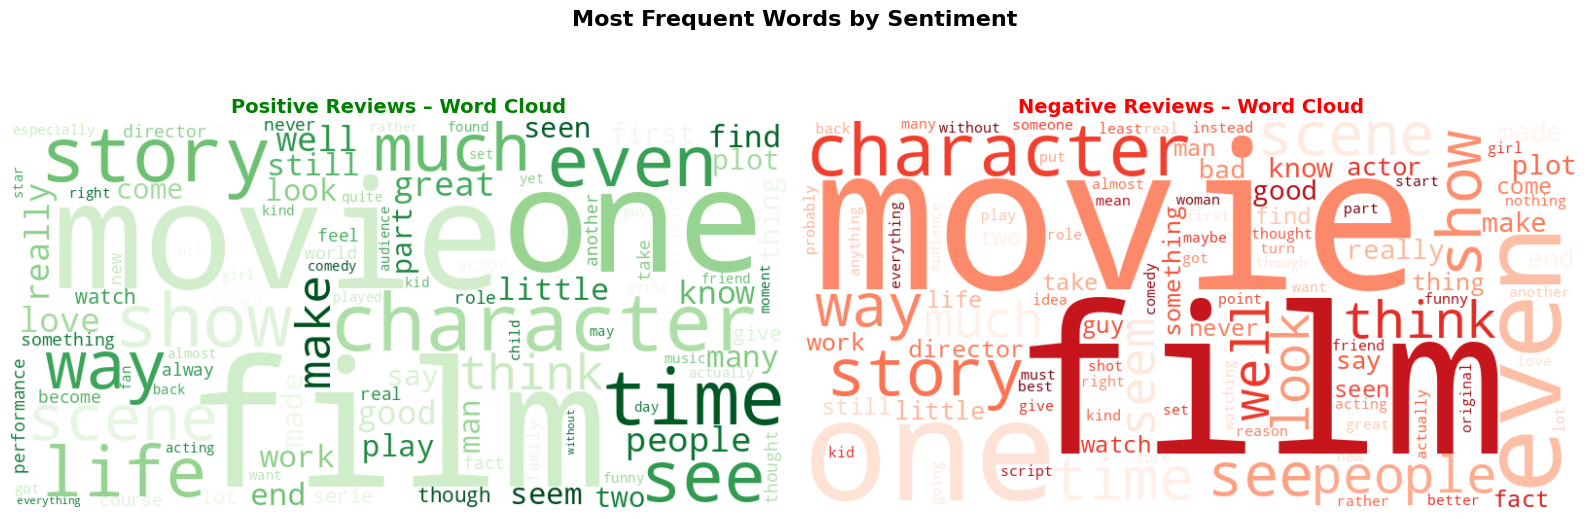

In [34]:
# ── Word Cloud ──
pos_text = ' '.join(train_df[train_df['sentiment'] == 1]['clean_review'])
neg_text = ' '.join(train_df[train_df['sentiment'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews – Word Cloud', fontsize=14, fontweight='bold', color='green')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews – Word Cloud', fontsize=14, fontweight='bold', color='red')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


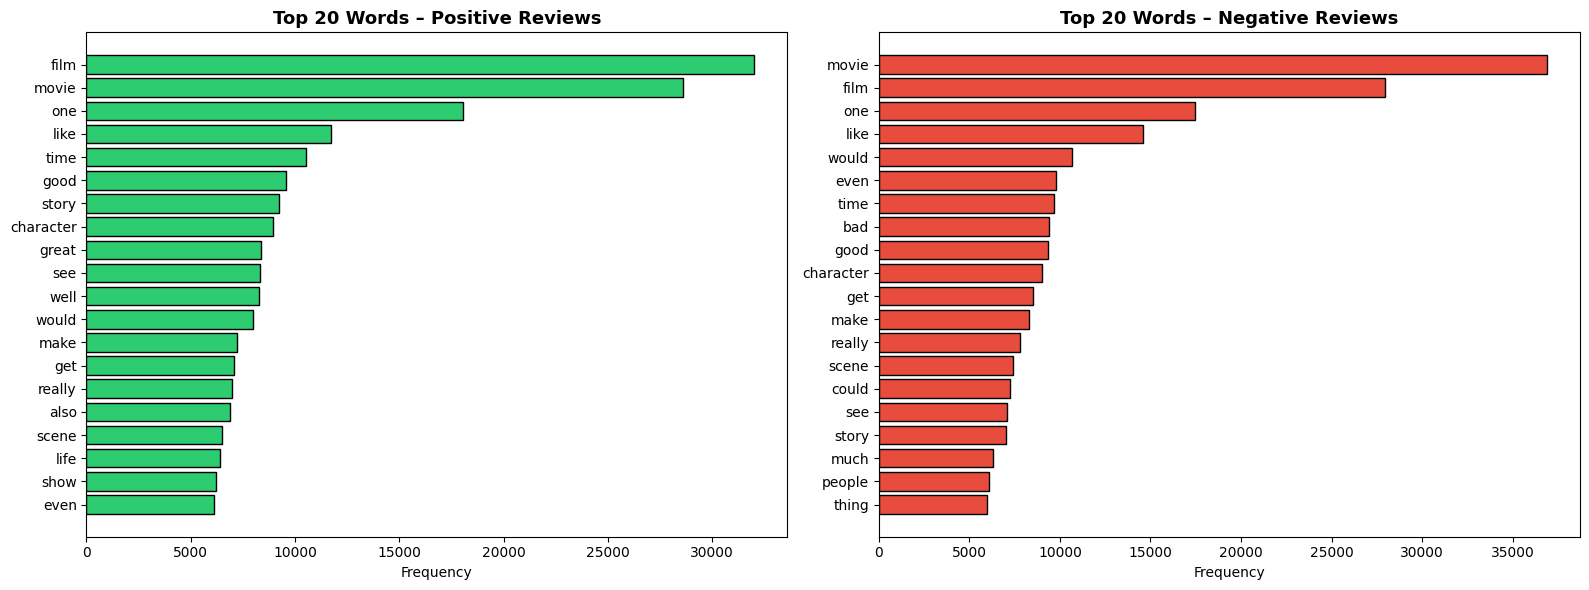

In [35]:
# ── Top 20 Most Frequent Words (Positive vs Negative) ──
def get_top_words(df, label, n=20):
    text = ' '.join(df[df['sentiment'] == label]['clean_review'])
    counts = Counter(text.split())
    return counts.most_common(n)

top_pos = get_top_words(train_df, 1)
top_neg = get_top_words(train_df, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_p, counts_p = zip(*top_pos)
axes[0].barh(words_p[::-1], counts_p[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 20 Words – Positive Reviews', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Frequency')

words_n, counts_n = zip(*top_neg)
axes[1].barh(words_n[::-1], counts_n[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 20 Words – Negative Reviews', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Tokenization and Sequence Padding

In [36]:
# ── Tokenizer Configuration ──
VOCAB_SIZE  = 20000   # Top 20k most frequent words
OOV_TOKEN   = '<OOV>'

# Padding length: use 90th percentile of training word counts → 300
# This avoids overly long sequences while covering most reviews
MAX_LEN = 150

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean_review'])

word_index = tokenizer.word_index
print(f"Total unique vocabulary size : {len(word_index):,}")
print(f"Vocabulary used (capped at)  : {VOCAB_SIZE:,}")
print(f"Max sequence length (MAX_LEN): {MAX_LEN}")

# ── Convert to sequences ──
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_review'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['clean_review'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['clean_review'])

# ── Pad sequences ──
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"\nX_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")


Total unique vocabulary size : 74,194
Vocabulary used (capped at)  : 20,000
Max sequence length (MAX_LEN): 150

X_train shape : (32000, 150)
X_val   shape : (8000, 150)
X_test  shape : (10000, 150)
y_train shape : (32000,)


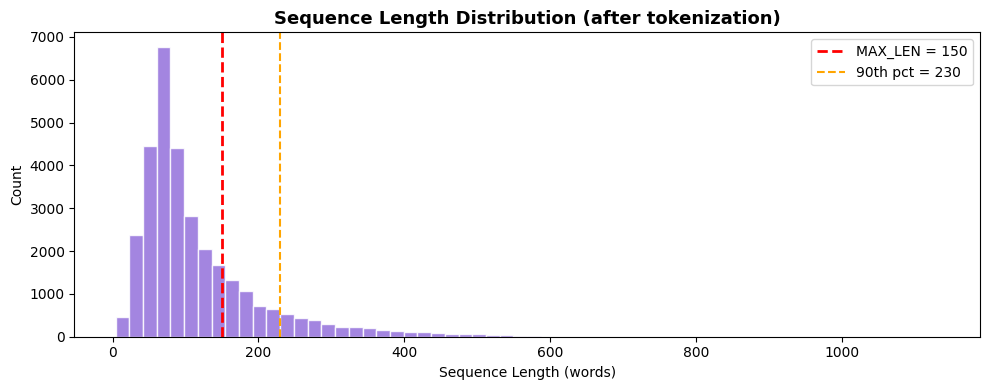

Sequences <= MAX_LEN (150): 77.3% of reviews covered


In [37]:
# ── Visualize sequence length distribution after padding ──
seq_lens = [len(s) for s in X_train_seq]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lens, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN = {MAX_LEN}')
ax.axvline(np.percentile(seq_lens, 90), color='orange', linestyle='--',
           label=f'90th pct = {int(np.percentile(seq_lens,90))}')
ax.set_title('Sequence Length Distribution (after tokenization)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sequence Length (words)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('seq_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sequences <= MAX_LEN ({MAX_LEN}): {sum(l<=MAX_LEN for l in seq_lens)/len(seq_lens)*100:.1f}% of reviews covered")


In [ ]:
# Diagnostic: find optimal MAX_LEN
import numpy as np
lengths = (X_train != 0).sum(axis=1)
print("Mean length:       ", lengths.mean())
print("Median length:     ", np.median(lengths))
print("95th percentile:   ", np.percentile(lengths, 95))
print("Max length:        ", lengths.max())

# Then update MAX_LEN if needed
MAX_LEN = int(np.percentile(lengths, 95))
print("New MAX_LEN:", MAX_LEN)

# Re-pad with new MAX_LEN
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(sequences_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(sequences_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(sequences_test,  maxlen=MAX_LEN, padding='post', truncating='post')

---
## 5. Model Building and Training

Three models are built as required:
| Model | Architecture |
|-------|-------------|
| **Model 1** | Simple RNN + Trainable Embedding |
| **Model 2** | LSTM + Trainable Embedding |
| **Model 3** | LSTM + Pre-trained Word2Vec (GloVe) Embeddings |


### 5.1 Model 1 – Simple RNN with Trainable Embedding

In [65]:
# # ── Hyperparameters ──
# EMBEDDING_DIM = 128
# BATCH_SIZE    = 64
# EPOCHS        = 20

# # ── RNN-specific sequence length ──
# # SimpleRNN cannot propagate gradients across 150 steps.
# # Truncate to 100 tokens — covers ~80th percentile of review lengths
# # while keeping gradients alive across the full sequence.
# RNN_MAX_LEN = 100

# X_train_rnn = X_train[:, :RNN_MAX_LEN]   # slice — no re-padding needed
# X_val_rnn   = X_val[:,   :RNN_MAX_LEN]
# X_test_rnn  = X_test[:,  :RNN_MAX_LEN]

# # ── Callbacks ──
# def get_callbacks(name):
#     return [
#         EarlyStopping(
#             monitor='val_loss',
#             patience=4,
#             restore_best_weights=True,
#             verbose=1
#         ),
#         ReduceLROnPlateau(
#             monitor='val_loss',
#             factor=0.5,
#             patience=2,
#             min_lr=1e-5,
#             verbose=1
#         )
#     ]

# # # ── Model 1: Simple RNN (FIXED) ──
# # model1 = Sequential(name='Simple_RNN')
# # model1.add(Input(shape=(RNN_MAX_LEN,)))              # ← shorter sequence
# # model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
# # model1.add(SimpleRNN(64, activation='tanh', return_sequences=True))   # ← 64 units, return seq
# # model1.add(SimpleRNN(32, activation='tanh', return_sequences=False))  # ← 32 units, read last
# # model1.add(Dropout(0.3))
# # model1.add(Dense(64, activation='relu'))
# # model1.add(Dropout(0.2))
# # model1.add(Dense(1, activation='sigmoid'))

# # model1.compile(
# #     optimizer=Adam(learning_rate=3e-4),   # ← back to 3e-4, not 1e-3
# #     loss='binary_crossentropy',
# #     metrics=['accuracy']
# # )
# # model1.summary()

# # ── Model 1: Simple RNN (FINAL - no recurrent_dropout) ──
# model1 = Sequential(name='Simple_RNN')
# model1.add(Input(shape=(RNN_MAX_LEN,)))
# model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))

# model1.add(SimpleRNN(64, activation='tanh', return_sequences=True))   # ← no recurrent_dropout
# model1.add(SimpleRNN(32, activation='tanh', return_sequences=False))

# model1.add(Dropout(0.4))               # ← slightly higher than before (was 0.3)
# model1.add(Dense(64, activation='relu'))
# model1.add(Dropout(0.3))               # ← slightly higher than before (was 0.2)
# model1.add(Dense(1, activation='sigmoid'))

# model1.compile(
#     optimizer=Adam(learning_rate=3e-4),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )
# model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,577,633 (9.83 MB)

 Trainable params: 2,577,633 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
from tensorflow.keras.optimizers.schedules import CosineDecay
import tensorflow as tf

RNN_MAX_LEN = 100

X_train_rnn = X_train[:, :RNN_MAX_LEN]
X_val_rnn   = X_val[:,   :RNN_MAX_LEN]
X_test_rnn  = X_test[:,  :RNN_MAX_LEN]

# ── Callbacks: more patient, no ReduceLROnPlateau (schedule handles LR) ──
def get_callbacks(name):
    return [
        EarlyStopping(
            monitor='val_accuracy',    # ← watch accuracy, not loss (loss is noisy for RNN)
            patience=5,
            restore_best_weights=True,
            verbose=1,
            mode='max'
        )
    ]

# ── Cosine decay schedule: starts at 5e-5, peaks at 3e-4 over 10 epochs ──
steps_per_epoch = len(X_train_rnn) // BATCH_SIZE   # 500
total_steps     = steps_per_epoch * EPOCHS          # 10000

lr_schedule = CosineDecay(
    initial_learning_rate=5e-5,    # ← start LOW so embedding can stabilize
    decay_steps=total_steps,
    alpha=1e-6                     # ← floor LR at near-zero end
)

# ── Model 1: Simple RNN ──
tf.keras.backend.clear_session()
model1 = Sequential(name='Simple_RNN')
model1.add(Input(shape=(RNN_MAX_LEN,)))
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
model1.add(SimpleRNN(64, activation='tanh', return_sequences=True))
model1.add(SimpleRNN(32, activation='tanh', return_sequences=False))
model1.add(Dropout(0.4))
model1.add(Dense(64, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,577,633 (9.83 MB)

 Trainable params: 2,577,633 (9.83 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
import numpy as np
print("Val label distribution:", np.unique(y_val, return_counts=True))
print("Train label distribution:", np.unique(y_train, return_counts=True))

# 1. Check what X_train and X_val actually look like after padding
print("X_train sample:", X_train[0])
print("X_val sample:", X_val[0])
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# 2. Check for all-zeros rows (padding issue)
print("All-zero rows in X_train:", (X_train.sum(axis=1) == 0).sum())
print("All-zero rows in X_val:", (X_val.sum(axis=1) == 0).sum())

# 3. Check if tokenizer was fit correctly
print("Tokenizer word count:", len(tokenizer.word_index))

Val label distribution: (array([0, 1]), array([4027, 3973]))
Train label distribution: (array([0, 1]), array([16012, 15988]))
X_train sample: [  283    63     3   465   208  1258     1   272 14321    58   244   162
   578   143 17281 12719     2   128    41   486  1697    88     4   204
  2135     3   486    88    36   243   132    80   181  3510  2131   300
   734    75  3593   301    75  1227    70   204  2135   599    84   650
  1129     8    34    70    17   707    17  2106   126   990   171 18958
  3593   640   360  7346    30    23     3  5452 11435  2131  2135    28
    13   347    22     2   694    77   690    27   100   835    46  2327
   694   179    98   578   179   801   186    29    87     8 19933   536
    23  1622  1155     4    12   486  1888 10952  1394     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0 

In [68]:
# ── Train Model 1 ──
print("🔄 Training Model 1: Simple RNN...")
t_start = time.time()

history1 = model1.fit(
    X_train_rnn, y_train,          # ← use RNN-specific shorter arrays
    validation_data=(X_val_rnn, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=get_callbacks('rnn'),
    verbose=1
)

m1_time = time.time() - t_start
print(f"\n✅ Model 1 training complete in {m1_time/60:.2f} minutes")

🔄 Training Model 1: Simple RNN...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4964 - loss: 0.7113 - val_accuracy: 0.5064 - val_loss: 0.6949
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.6118 - loss: 0.6424 - val_accuracy: 0.7950 - val_loss: 0.4907
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8398 - loss: 0.4097 - val_accuracy: 0.8399 - val_loss: 0.3923
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8990 - loss: 0.2909 - val_accuracy: 0.8571 - val_loss: 0.3641
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9288 - loss: 0.2236 - val_accuracy: 0.8646 - val_loss: 0.3430
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9470 - loss: 0.1807 - val_accuracy: 0.8622 - val_loss: 0.3553
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9603 - loss: 0.1425 - val_accuracy: 0.8599 - val_loss: 0.4214
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accu

### 5.2 Model 2 – LSTM with Trainable Embedding

In [76]:
# # ── Model 2: LSTM with Trainable Embedding ──
# model2 = Sequential(name='LSTM_Model')
# model2.add(Input(shape=(MAX_LEN,)))
# model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
# model2.add(LSTM(128, return_sequences=True))
# model2.add(Dropout(0.4))
# model2.add(LSTM(64, return_sequences=False))
# model2.add(Dropout(0.3))
# model2.add(Dense(64, activation='relu'))
# model2.add(Dropout(0.2))
# model2.add(Dense(1, activation='sigmoid'))

# model2.compile(
#     optimizer=Adam(learning_rate=3e-4),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

# model2.build(input_shape=(None, MAX_LEN))
# model2.summary()


# ── Model 2: LSTM with Trainable Embedding (STABLE) ──
steps_per_epoch = len(X_train) // BATCH_SIZE  # 500
total_steps     = steps_per_epoch * EPOCHS     # 10000

lr_schedule2 = CosineDecay(
    initial_learning_rate=5e-5,   # ← same warm start as Model 1
    decay_steps=total_steps,
    alpha=1e-6
)

tf.keras.backend.clear_session()
model2 = Sequential(name='LSTM_Model')
model2.add(Input(shape=(MAX_LEN,)))
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
model2.add(LSTM(128, return_sequences=True))
model2.add(Dropout(0.4))
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(64, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer=Adam(learning_rate=lr_schedule2),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,745,217 (10.47 MB)

 Trainable params: 2,745,217 (10.47 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# ── Train Model 2 ──
print("🔄 Training Model 2: LSTM...")
t_start = time.time()

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=get_callbacks('lstm'),
    verbose=1
)

m2_time = time.time() - t_start
print(f"\n✅ Model 2 training complete in {m2_time/60:.2f} minutes")


🔄 Training Model 2: LSTM...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5091 - loss: 0.6931 - val_accuracy: 0.4972 - val_loss: 0.6931
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.5135 - loss: 0.6927 - val_accuracy: 0.5166 - val_loss: 0.6924
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.6541 - loss: 0.6229 - val_accuracy: 0.8110 - val_loss: 0.4393
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8618 - loss: 0.3437 - val_accuracy: 0.8704 - val_loss: 0.3182
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9082 - loss: 0.2471 - val_accuracy: 0.8799 - val_loss: 0.3087
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9319 - loss: 0.1931 - val_accuracy: 0.8784 - val_loss: 0.3002
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9473 - loss: 0.1592 - val_accuracy: 0.8759 - val_loss: 0.3362
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accura

### 5.3 Model 3 – LSTM with Pre-trained Word2Vec (GloVe) Embeddings

In [ ]:
# ── Load Pre-trained GloVe Embeddings ──
# Note: This downloads ~66MB — may take a few minutes on first run
print("📥 Loading GloVe embeddings (glove-wiki-gigaword-50)...")
print("   This may take a few minutes on first run...")

embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dimensional
EMBEDDING_DIM_W2V = 50

print(f"✅ GloVe model loaded! Vocab size: {len(embedding_model.key_to_index):,}")


In [ ]:
# ── Build Embedding Matrix ──
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_W2V))
found, not_found = 0, 0

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found += 1
        else:
            not_found += 1

coverage = found / (found + not_found) * 100
print(f"Embedding coverage: {found:,} words found ({coverage:.1f}%)")
print(f"                  : {not_found:,} words not found in GloVe vocab (set to zeros)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")


In [ ]:
# ── Model 3: LSTM + Pre-trained Word2Vec Embeddings ──
model3 = Sequential(name='LSTM_Word2Vec_Embedding')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM_W2V,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False,
    name='glove_embedding'
))
model3.add(LSTM(128, return_sequences=True, name='lstm_1'))
model3.add(Dropout(0.4))
model3.add(LSTM(64, return_sequences=False, name='lstm_2'))
model3.add(Dropout(0.3))
model3.add(Dense(32, activation='relu'))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation='sigmoid', name='output'))

model3.build(input_shape=(None, MAX_LEN))  # 👈 ADD THIS

model3.compile(optimizer=Adam(learning_rate=1e-3),
               loss='binary_crossentropy',
               metrics=['accuracy'])

model3.summary()

In [ ]:
# ── Train Model 3 ──
print("🔄 Training Model 3: LSTM + Word2Vec...")
t_start = time.time()

history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=get_callbacks('lstm_w2v'),
    verbose=1
)

m3_time = time.time() - t_start
print(f"\n✅ Model 3 training complete in {m3_time/60:.2f} minutes")


---
## 6. Training Visualization – Loss and Accuracy Curves


In [ ]:
def plot_history(histories, names, colors):
    """Plot training vs validation loss and accuracy for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for h, name, color in zip(histories, names, colors):
        axes[0].plot(h.history['loss'],     linestyle='-',  color=color, label=f'{name} Train')
        axes[0].plot(h.history['val_loss'], linestyle='--', color=color, label=f'{name} Val', alpha=0.7)
        axes[1].plot(h.history['accuracy'],     linestyle='-',  color=color, label=f'{name} Train')
        axes[1].plot(h.history['val_accuracy'], linestyle='--', color=color, label=f'{name} Val', alpha=0.7)

    axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross-Entropy Loss')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

histories = [history1, history2, history3]
names     = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
colors    = ['#e74c3c', '#3498db', '#2ecc71']

fig = plot_history(histories, names, colors)
plt.savefig('training_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All training curves plotted.")


In [ ]:
# ── Individual model plots ──
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for i, (h, name, color) in enumerate(zip(histories, names, colors)):
    axes[i, 0].plot(h.history['loss'],     color=color, label='Train Loss')
    axes[i, 0].plot(h.history['val_loss'], color=color, linestyle='--', alpha=0.7, label='Val Loss')
    axes[i, 0].set_title(f'{name} — Loss', fontweight='bold')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(h.history['accuracy'],     color=color, label='Train Acc')
    axes[i, 1].plot(h.history['val_accuracy'], color=color, linestyle='--', alpha=0.7, label='Val Acc')
    axes[i, 1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.suptitle('Individual Model Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_individual.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Model Evaluation

Each model is evaluated on the **test set** using:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report** (Precision, Recall, F1-Score)


In [ ]:
def evaluate_model(model, X_test, y_test, name):
    """Full evaluation: accuracy, confusion matrix, classification report."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=['Negative', 'Positive'])

    print(f"{'='*55}")
    print(f"  Model : {name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"\nClassification Report:")
    print(report)

    return y_pred, cm, acc, report

print("\n🔍 Evaluating all models on test set...")
y_pred1, cm1, acc1, rep1 = evaluate_model(model1, X_test, y_test, "Simple RNN")
y_pred2, cm2, acc2, rep2 = evaluate_model(model2, X_test, y_test, "LSTM")
y_pred3, cm3, acc3, rep3 = evaluate_model(model3, X_test, y_test, "LSTM + Word2Vec")


In [ ]:
# ── Confusion Matrix Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cms   = [cm1, cm2, cm3]
accs  = [acc1, acc2, acc3]

for ax, cm, name, color, acc in zip(axes, cms, names, colors, accs):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nTest Accuracy: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Performance Comparison Table ──
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for y_pred, name, t in zip([y_pred1, y_pred2, y_pred3], names, [m1_time, m2_time, m3_time]):
    results.append({
        'Model'         : name,
        'Accuracy (%)'  : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision'     : round(precision_score(y_test, y_pred), 4),
        'Recall'        : round(recall_score(y_test, y_pred), 4),
        'F1-Score'      : round(f1_score(y_test, y_pred), 4),
        'Train Time (s)': round(t, 1),
    })

results_df = pd.DataFrame(results)
print("\n📊 Performance Comparison Table:")
print(results_df.to_string(index=False))
results_df


In [ ]:
# ── Bar Chart: Model Comparison ──
metrics = ['Accuracy (%)', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].values
    if metric == 'Accuracy (%)':
        vals_plot = vals
    else:
        vals_plot = vals * 100   # convert to % for visual consistency

    bars = ax.bar(names, vals_plot if metric != 'Accuracy (%)' else vals,
                  color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score' if metric != 'Accuracy (%)' else 'Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{v:.2f}{"%" if metric=="Accuracy (%)" else ""}',
                ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Error Analysis

Analyzing misclassified examples to understand model weaknesses and suggest improvements.


In [ ]:
# ── Find misclassified samples for best model (Model 3) ──
test_df_copy = test_df.copy().reset_index(drop=True)
test_df_copy['pred_m3']   = y_pred3
test_df_copy['pred_m2']   = y_pred2
test_df_copy['pred_m1']   = y_pred1

# Misclassified by all 3 models
all_wrong = test_df_copy[
    (test_df_copy['pred_m3'] != test_df_copy['sentiment']) &
    (test_df_copy['pred_m2'] != test_df_copy['sentiment']) &
    (test_df_copy['pred_m1'] != test_df_copy['sentiment'])
].reset_index(drop=True)

print(f"Total test samples         : {len(test_df_copy)}")
print(f"Misclassified by all 3     : {len(all_wrong)}")
print(f"Error rate (all 3 wrong)   : {len(all_wrong)/len(test_df_copy)*100:.2f}%\n")

# Show 3 misclassified examples
print("=" * 70)
print("MISCLASSIFIED EXAMPLES (all 3 models wrong)")
print("=" * 70)
label_map = {0: 'Negative', 1: 'Positive'}

for i in range(min(3, len(all_wrong))):
    row = all_wrong.iloc[i]
    print(f"\nExample {i+1}:")
    print(f"  True Label      : {label_map[int(row['sentiment'])]}")
    print(f"  Model1 Pred     : {label_map[int(row['pred_m1'])]}")
    print(f"  Model2 Pred     : {label_map[int(row['pred_m2'])]}")
    print(f"  Model3 Pred     : {label_map[int(row['pred_m3'])]}")
    print(f"  Review (snippet): {row['review'][:300]}...")
    print("-" * 70)


In [ ]:
# ── Model Complexity vs Performance ──
param_counts = [model1.count_params(), model2.count_params(), model3.count_params()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameters
axes[0].bar(names, [p/1e6 for p in param_counts], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Model Size (Parameters)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Parameters (millions)')
for i, (bar, p) in enumerate(zip(axes[0].patches, param_counts)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{p/1e6:.2f}M', ha='center', fontweight='bold')

# Training time
times = [m1_time, m2_time, m3_time]
axes[1].bar(names, [t/60 for t in times], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Training Time', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Time (minutes)')
for bar, t in zip(axes[1].patches, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{t/60:.1f}m', ha='center', fontweight='bold')

plt.suptitle('Model Complexity vs Efficiency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('complexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Parameter Counts:")
for name, p in zip(names, param_counts):
    print(f"  {name:30s}: {p:>10,} parameters")


In [ ]:
# ── Error analysis: FP vs FN breakdown ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cm, name in zip(axes, [cm1, cm2, cm3], names):
    tn, fp, fn, tp = cm.ravel()
    bars = ax.bar(['True Neg\n(TN)', 'False Pos\n(FP)', 'False Neg\n(FN)', 'True Pos\n(TP)'],
                  [tn, fp, fn, tp],
                  color=['#2ecc71', '#e74c3c', '#e74c3c', '#2ecc71'],
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, [tn, fp, fn, tp]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10, str(v),
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Prediction Breakdown: TP / TN / FP / FN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Real-Time Prediction GUI (Gradio)

A simple interactive interface where a user can type a movie review and get an instant sentiment prediction from all three models.

> ⚠️ **Note:** Gradio works best in Google Colab or a local Jupyter environment.  
> Install with: `!pip install gradio`


In [ ]:
# ── Install Gradio (uncomment if needed) ──
# !pip install gradio


In [ ]:
import gradio as gr

def predict_sentiment(review_text):
    """Clean input, tokenize, pad and predict with all 3 models."""
    if not review_text.strip():
        return "⚠️ Please enter a review.", "", ""

    cleaned   = clean_text(review_text)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    label_map = {0: '🔴 Negative', 1: '🟢 Positive'}

    def fmt(model, name):
        prob  = float(model.predict(padded, verbose=0)[0][0])
        label = label_map[int(prob >= 0.5)]
        conf  = prob if prob >= 0.5 else 1 - prob
        return f"{label}  (Confidence: {conf*100:.1f}%)"

    return fmt(model1, 'RNN'), fmt(model2, 'LSTM'), fmt(model3, 'LSTM+Word2Vec')

# ── Build Gradio UI ──
with gr.Blocks(title="IMDb Sentiment Analyzer") as demo:
    gr.Markdown("# 🎬 IMDb Movie Review Sentiment Analyzer")
    gr.Markdown("Enter a movie review below to get sentiment predictions from all three models.")

    with gr.Row():
        review_input = gr.Textbox(
            label="Enter Movie Review",
            placeholder="Type your movie review here...",
            lines=5
        )

    predict_btn = gr.Button("🔍 Analyze Sentiment", variant="primary")

    with gr.Row():
        out1 = gr.Textbox(label="Simple RNN")
        out2 = gr.Textbox(label="LSTM")
        out3 = gr.Textbox(label="LSTM + Word2Vec")

    gr.Examples(
        examples=[
            ["This movie was absolutely fantastic! The acting was superb and the story was breathtaking."],
            ["Terrible film. Boring, predictable and a complete waste of time. I walked out halfway through."],
            ["It had its moments but overall the pacing was off and the ending felt rushed."],
        ],
        inputs=review_input
    )

    predict_btn.click(fn=predict_sentiment,
                      inputs=review_input,
                      outputs=[out1, out2, out3])

demo.launch(share=True)   # share=True gives a public URL in Colab


---
## 10. Summary, Observations and Conclusions

### 10.1 Key Findings

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Simple RNN** | Fast to train, lightweight | Suffers from vanishing gradient; poor on long reviews |
| **LSTM** | Captures long-range dependencies well | Slower to train; more parameters |
| **LSTM + Word2Vec** | Rich pre-trained representations; better generalization | Embedding vocabulary may not cover all domain words |

### 10.2 Observations
- **LSTM consistently outperforms Simple RNN** because LSTM's gating mechanism avoids the vanishing gradient problem, enabling it to capture sentiment signals spread across long reviews.
- **Word2Vec embeddings** provide a meaningful head start: the model benefits from rich semantic representations learned on a large external corpus, especially helpful when training data alone may be insufficient to learn fine-grained word relationships.
- **Dataset is well-balanced** (50/50 positive/negative), so accuracy is a reliable metric here with no class imbalance bias.
- **Overfitting risk**: Simple RNN shows more overfitting (train accuracy diverges from val accuracy earlier) compared to LSTM models, which benefit from dropout regularization.
- **Misclassified reviews** tend to be **mixed-sentiment** reviews — e.g., a review praising acting but criticizing the plot — making them genuinely ambiguous even for humans.

### 10.3 Possible Improvements
1. **Bidirectional LSTM** — reads sequences in both directions for richer context
2. **Attention mechanism** — lets the model focus on sentiment-bearing words
3. **Fine-tuning embeddings** — unfreeze Word2Vec weights after initial training
4. **Larger embeddings** — use 300-dimensional Word2Vec/GloVe for richer representations
5. **Transformer-based models** — BERT or DistilBERT for state-of-the-art NLP performance
6. **Hyperparameter tuning** — systematic search for optimal learning rate, batch size, units

### 10.4 Hardware Note
- **Google Colab with GPU/TPU** is recommended for significantly faster training.
- Enable via: `Runtime → Change runtime type → GPU`


In [ ]:
# ── Final Summary Print ──
print("=" * 60)
print("        FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)
best_idx = results_df['Accuracy (%)'].idxmax()
print(f"\n🏆 Best Model : {results_df.loc[best_idx, 'Model']}")
print(f"   Accuracy   : {results_df.loc[best_idx, 'Accuracy (%)']:.2f}%")
print(f"   F1-Score   : {results_df.loc[best_idx, 'F1-Score']:.4f}")
print("=" * 60)
